In [86]:
import pandas as pd
import numpy as np
import gdown
from dotenv import load_dotenv
import os
import seaborn as sns
import matplotlib.pyplot as plt

In [126]:
#********************** Metodos e Variaveis Globas **********************
def ajustar_regiao(df, nome_coluna,id, nome_regiao): 
    df[nome_coluna] = df[nome_coluna].replace({id: nome_regiao})
    return df

def renomear_colunas(df, cols_antigas, cols_novas):
    mapeamento = dict(zip(cols_antigas, cols_novas))
    return df.rename(columns=mapeamento)


colunas_antigas = ['tx_resp_q01',
                   'tx_resp_q08',            #Nome das colunas antes de alterar
                  'tx_resp_q09',
                  'tx_resp_q10c',
                  'tx_resp_q10e',
                  'tx_resp_q19',
                  'tx_resp_q20',
                  'tx_resp_q23i',
                  'tx_resp_q21e',
                  'tx_resp_q21d',
                  'tx_resp_q21c',
                  'tx_resp_q21a', 
                  'tx_resp_q23a', 
                  'tx_resp_q23b',
                  'tx_resp_q17',
                  'tx_resp_q14',
                  'id_serie', 
                  'nu_tipo_nivel_inse',
                  'tx_resp_q02'
                  ]
                

colunas_novas = ['Genero_Alunos', 
                 'Escolaridade_Mae',         #Nome das colunas apos alterar os nomes 
                 'Escolaridade_Pai',
                 'Incentivo_Estudos_Pais',
                 'Incentivo_Presenca_Pais',
                 'Reprovacao',
                 'Abandono_Escola',
                 'Incentivo_Estudos_Professores',
                 'Tempo_Lazer',
                 'Tempo_Trabalho_Fora', 
                 'Tempo_Trabalho_Casa',
                 'Tempo_Estudos_Fora', 
                 'Interesse_Ensino',
                 'Motivacao_Estudos',
                 'Idade_Inicio_Estudos', 
                 'Tempo_Viagem_Escola',
                 'Categoria_Ensino',
                 'Categoria_Socioeconomica',
                 'idade_aluno'
                 ]
                 

variaveis_criticas = [
                'Genero_Alunos',
                'Escolaridade_Mae',         
                 'Escolaridade_Pai',
                 'Incentivo_Estudos_Pais',
                 'Incentivo_Presenca_Pais',
                 'Reprovacao',
                 'Abandono_Escola',
                 'Incentivo_Estudos_Professores',
                 'Tempo_Lazer',
                 'Tempo_Trabalho_Fora', 
                 'Tempo_Trabalho_Casa',
                 'Tempo_Estudos_Fora', 
                 'Interesse_Ensino',
                 'Motivacao_Estudos',
                 'Idade_Inicio_Estudos', 
                 'Tempo_Viagem_Escola']

mapeamento_evasao = {
    'Nunca.': 0,
    'Sim, uma vez.': 1,
    'Sim, duas vezes ou mais.': 2,
    '.': np.nan,
    '*': np.nan
}

mapeamento_idade = {
    '16 anos ou menos.': 16,
    '17 anos.': 17,
    '18 anos.': 18,
    '19 anos.': 19,
    '20 anos.': 20,
    '21 anos ou mais.': 21,
    'Branco': np.nan,
    'Nulo': np.nan
}


In [ ]:
load_dotenv() #Carregando variáveis do ambiente

In [60]:
id_arquivo = os.getenv("id_arquivo")
url = os.getenv("url")
url_arquivo = f'{url}{id_arquivo}'

In [ ]:
#Nome do arquivo CSV
output = 'base_inep.csv'

# O gdown consegue "pular" o aviso de vírus de arquivos grandes
#Download do CSV filtrado com os dados de SP
gdown.download(url_arquivo, output, quiet=False)

df = pd.read_csv(output, sep=',', encoding='utf-8')

### Tratamento para DataFrame com variáveis de interesse e substituição de valores preenchidos para seus respectivos significados

In [77]:
df_filtrado = df[(df["IN_PUBLICA"] == 1) & (df["ID_UF"] == 35)]
df_filtrado = ajustar_regiao(df_filtrado, 'ID_UF', 35, 'São Paulo')


In [ ]:
df_filtrado

In [64]:
df_dicionario = pd.read_csv('dicionario_34EM.csv', sep=';', skiprows=99)

In [65]:
df_dicionario['Variável'] = df_dicionario['Variável'].ffill()

In [ ]:
df_variaveis = df_variaveis.replace({
    np.nan: 'NULO',
    '.': 'BRANCO',
    '*': 'NULO'
})

In [67]:
cols_preencher = [
    'Variável',
    'Tipo',
    'Tamanho',
    'Código da Questão',
    'Descrição (texto da pergunta)'
]

df_dicionario[cols_preencher] = df_dicionario[cols_preencher].ffill()

In [68]:
mapas = {}

for var in df_dicionario['Variável'].unique():
    temp = df_dicionario[df_dicionario['Variável'] == var]
    
    mapa = dict(zip(temp['Código da opção de resposta'], 
                    temp['Texto da opção de resposta']))
    
    mapas[var] = mapa

In [ ]:
mapa

In [ ]:
for col in df_variaveis.columns:
    if col in mapas:
        df_variaveis[col] = df_variaveis[col].map(mapas[col]).fillna(df_variaveis[col])

In [124]:
df_filtrado

,Genero_Alunos,Escolaridade_Mae,Escolaridade_Pai,Incentivo_Estudos_Pais,Incentivo_Presenca_Pais,Reprovacao,Abandono_Escola,Incentivo_Estudos_Professores,Tempo_Lazer,Tempo_Trabalho_Fora,Tempo_Trabalho_Casa,Tempo_Estudos_Fora,Interesse_Ensino,Motivacao_Estudos,Idade_Inicio_Estudos,Tempo_Viagem_Escola,Categoria_Ensino,Categoria_Socioeconomica,idade_aluno
0,Branco,Branco,Branco,Branco,Branco,Branco,NaN,Branco,Branco,Branco,Branco,Branco,Branco,Branco,Branco,Branco,12,1,Branco
1,Feminino.,Não sei.,Não sei.,De vez em quando.,Sempre ou quase sempre.,Não.,0.0,Concordo totalmente.,Mais de 2 horas.,Não uso meu tempo para isso.,Entre 1 e 2 horas.,Não uso meu tempo para isso.,Discordo.,Discordo.,6 ou 7 anos.,Entre 30 minutos e uma hora.,12,6,17 anos.
2,Masculino.,Não sei.,Não sei.,Sempre ou quase sempre.,Sempre ou quase sempre.,Não.,0.0,Concordo totalmente.,Mais de 2 horas.,Não uso meu tempo para isso.,Menos de 1 hora.,Menos de 1 hora.,Concordo.,Concordo.,3 anos ou menos.,Entre 30 minutos e uma hora.,12,3,17 anos.
3,Masculino.,Ensino Médio completo.,Ensino Médio completo.,Sempre ou quase sempre.,Sempre ou quase sempre.,Não.,0.0,Concordo totalmente.,Mais de 2 horas.,Mais de 2 horas.,Menos de 1 hora.,Não uso meu tempo para isso.,Discordo.,Discordo.,4 ou 5 anos.,Entre 30 minutos e uma hora.,12,5,17 anos.
4,Masculino.,Ensino Fundamental completo.,Não sei.,Sempre ou quase sempre.,Sempre ou quase sempre.,Não.,0.0,Concordo totalmente.,Mais de 2 horas.,Mais de 2 horas.,Entre 1 e 2 horas.,Menos de 1 hora.,Discordo.,Discordo.,4 ou 5 anos.,Entre 30 minutos e uma hora.,12,3,17 anos.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
542063,Masculino.,Ensino Médio completo.,Ensino Médio completo.,De vez em quando.,Sempre ou quase sempre.,Não.,0.0,Concordo.,Mais de 2 horas.,Não uso meu tempo para isso.,Mais de 2 horas.,Menos de 1 hora.,Concordo.,Discordo.,3 anos ou menos.,Menos de 30 minutos.,12,6,18 anos.
542064,Masculino.,"Ensino Fundamental, até o 5º ano.",Não completou o 5º ano do Ensino Fundamental.,De vez em quando.,Sempre ou quase sempre.,Não.,0.0,Concordo.,Mais de 2 horas.,Mais de 2 horas.,Entre 1 e 2 horas.,Menos de 1 hora.,Discordo totalmente.,Concordo.,4 ou 5 anos.,Menos de 30 minutos.,12,3,18 anos.
542065,Feminino.,Ensino Médio completo.,Ensino Médio completo.,Sempre ou quase sempre.,Sempre ou quase sempre.,Não.,0.0,Concordo totalmente.,Mais de 2 horas.,Mais de 2 horas.,Mais de 2 horas.,Mais de 2 horas.,Concordo totalmente.,Concordo totalmente.,6 ou 7 anos.,Menos de 30 minutos.,12,5,17 anos.
542066,Masculino.,Ensino Médio completo.,Ensino Médio completo.,Sempre ou quase sempre.,Sempre ou quase sempre.,Não.,0.0,Concordo totalmente.,Mais de 2 horas.,Mais de 2 horas.,Entre 1 e 2 horas.,Menos de 1 hora.,Discordo.,Discordo.,4 ou 5 anos.,Menos de 30 minutos.,12,4,18 anos.


In [127]:
df_filtrado['Abandono_Escola'].map(mapeamento_evasao)
df_filtrado['idade_aluno'].map(mapeamento_idade)

0          NaN
1         17.0
2         17.0
3         17.0
4         17.0
          ... 
542063    18.0
542064    18.0
542065    17.0
542066    18.0
542067    17.0
Name: idade_aluno, Length: 540962, dtype: float64

In [ ]:
df_filtrado['idade_aluno'].unique()

In [ ]:
df_filtradoTESTE

In [ ]:
# ==========================================
# 3. CONFIGURAÇÃO ESTÉTICA DO GRÁFICO (Padrão TCC)
# ==========================================
sns.set_theme(style="whitegrid")  # Fundo limpo com linhas de grade discretas
plt.figure(figsize=(8, 5))  # Aumentei levemente a largura para acomodar as 4 barras

# Definindo 4 cores para as categorias (Azul, Laranja, Vermelho, Cinza para nulos)
paleta_cores = ["#4682B4", "#EEAD0E", "#CD5C5C", "#A9A9A9"]

# Criando o gráfico de barras incluindo a string 'Nulo/Em Branco' onde houver NaN
ax = sns.countplot(
    x=df_filtrado["Abandono_Escola"].fillna("Nulo/Em Branco"),
    data=df_filtrado,
    palette=paleta_cores,
    order=[0.0, 1.0, 2.0, "Nulo/Em Branco"],  # Garante a ordem exata das barras
)

# Adicionando a contagem exata e o percentual em cima de cada barra
total = len(df_filtrado)
for p in ax.patches:
    height = p.get_height()
    if height > 0:  # Evita erro caso alguma barra esteja zerada
        percentage = f"{100 * height / total:.1f}%"
        # Adiciona o texto centralizado no topo da barra (padrão de milhar brasileiro)
        ax.annotate(
            f"{int(height):,}\n({percentage})".replace(",", "."),
            (p.get_x() + p.get_width() / 2.0, height),
            ha="center",
            va="center",
            xytext=(0, 12),
            textcoords="offset points",
            fontsize=10,
            fontweight="bold",
        )

# ==========================================
# 4. AJUSTE DE RÓTULOS E LIMITES (Padrão ABNT)
# ==========================================

plt.xlabel("Taxa de abandono", fontsize=11, labelpad=10)
plt.ylabel("Quantidade de Alunos", fontsize=11)

# Nomeando os rótulos das 4 colunas correspondentes no eixo X
plt.xticks(
    ticks=[0, 1, 2, 3],
    labels=[
        "Nunca",
        "Uma Vez",
        "Duas ou Mais",
        "Não Preenchido",
    ],
)

# Ajusta dinamicamente o limite do eixo Y com folga para as legendas
contagem_maxima = (
    df_filtrado["Abandono_Escola"].fillna("Nulo").value_counts().max()
)
plt.ylim(0, contagem_maxima * 1.15)

# Remove as bordas do topo e da direita para deixar o gráfico minimalista
sns.despine(left=True, bottom=True)

# Exibe o gráfico final
plt.tight_layout()
plt.show()

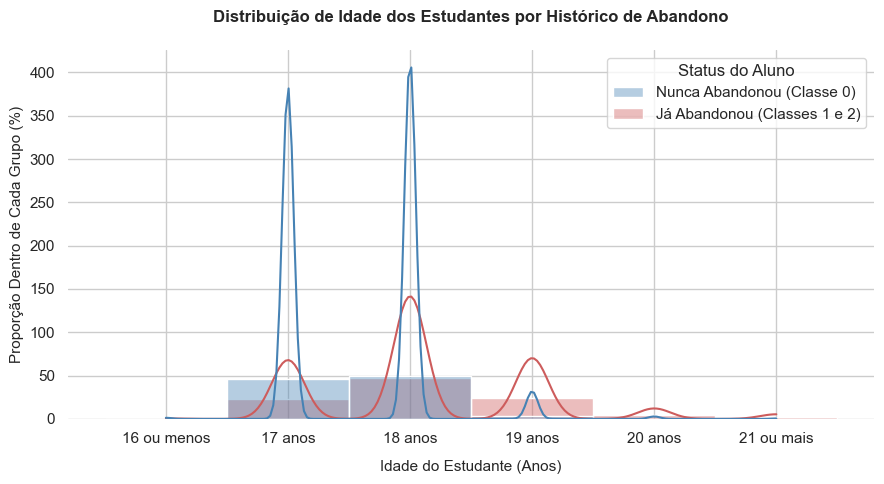

In [131]:
# Aplicando o mapeamento diretamente na coluna do seu df_filtrado
idade_mapeada = df_filtrado['idade_aluno'].map(mapeamento_idade)

# Agrupando o abandono em formato binário para a legenda do gráfico
status_abandono_mapeado = df_filtrado['Abandono_Escola'].map({
    0.0: 'Nunca Abandonou (Classe 0)',
    1.0: 'Já Abandonou (Classes 1 e 2)',
    2.0: 'Já Abandonou (Classes 1 e 2)'
})

# ==========================================
# 2. FILTRAGEM DOS VALORES VÁLIDOS (Sem NaN)
# ==========================================
# Criamos uma máscara para ignorar os registros que ficaram como NaN (Brancos e Nulos)
mascara_validos = idade_mapeada.notna() & status_abandono_mapeado.notna()

# Isolamos os vetores limpos que vão alimentar o gráfico diretamente
vetor_x_idade = idade_mapeada[mascara_validos].astype(int)
vetor_hue_status = status_abandono_mapeado[mascara_validos]

# ==========================================
# 3. CONFIGURAÇÃO ESTÉTICA DO HISTOGRAMA
# ==========================================
sns.set_theme(style="whitegrid")
plt.figure(figsize=(9, 5))

# Passando os vetores diretos para o Seaborn (à prova de erros de string)
ax = sns.histplot(
    x=vetor_x_idade,
    hue=vetor_hue_status,
    kde=True,              # Desenha a curva de densidade suave por cima das barras
    multiple="layer",      # Sobreposição transparente para comparar as duas curvas
    stat="percent",        # Normaliza a escala para porcentagem (0 a 100%)
    common_norm=False,     # Calcula a porcentagem isolada por grupo (evita distorções de tamanho)
    palette=["#4682B4", "#CD5C5C"], # Azul para Classe 0 e Vermelho para Risco
    bins=[15.5, 16.5, 17.5, 18.5, 19.5, 20.5, 21.5], # Centraliza a barra no número inteiro
    alpha=0.4,             # Transparência para enxergar onde as curvas se cruzam
    edgecolor="white"
)

# ==========================================
# 4. AJUSTES DE RÓTULOS E LIMITES (Padrão ABNT)
# ==========================================
plt.title("Distribuição de Idade dos Estudantes por Histórico de Abandono", fontsize=12, fontweight='bold', pad=20)
plt.xlabel("Idade do Estudante (Anos)", fontsize=11, labelpad=10)
plt.ylabel("Proporção Dentro de Cada Grupo (%)", fontsize=11)

# Alinhando as marcações do eixo X exatamente com as idades do SAEB
plt.xlim(15.2, 21.8)
plt.xticks(ticks=[16, 17, 18, 19, 20, 21], 
           labels=["16 ou menos", "17 anos", "18 anos", "19 anos", "20 anos", "21 ou mais"])

# Move a legenda para o canto superior direito de forma limpa
sns.move_legend(ax, "upper right", title="Status do Aluno")

# Limpa as bordas estruturais do gráfico
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()